# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Hasna Nur Saudah
- **Email:** cdcc180d6x1807@student.devacademy.id
- **ID Dicoding:** CDCC180D6X1807

## Menentukan Pertanyaan Bisnis

- **Bagaimana pengaruh musim (season) terhadap rata-rata jumlah peminjaman sepeda harian?**
- **Bagaimana pola peminjaman sepeda per jam pada hari kerja (workingday) dibandingkan hari libur?**

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
# Membaca berkas day.csv
day_df = pd.read_csv('data/day.csv')

# Membaca berkas hour.csv
hour_df = pd.read_csv('data/hour.csv')


**Insight:**
- `hour_df` berisi data penyewaan sepeda per jam.
- `day_df` berisi data penyewaan sepeda harian.
- Kedua dataset terdiri dari fitur umum seperti `dteday`, `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`, `casual`, `registered`, and `cnt`.

### Assessing Data

In [ ]:
print('====== ASSESSING: day.csv ======')
print('\n--- Info ---')
day_df.info()
print('\n--- Missing Values ---')
print(day_df.isnull().sum())
print('\n--- Duplikat ---')
print(f'Jumlah baris duplikat: {day_df.duplicated().sum()}')

print('====== ASSESSING: hour.csv ======')
print('\n--- Info ---')
hour_df.info()
print('\n--- Missing Values ---')
print(hour_df.isnull().sum())
print('\n--- Duplikat ---')
print(f'Jumlah baris duplikat: {hour_df.duplicated().sum()}')

====== ASSESSING: day.csv ======

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

--- Missing Values ---
instant       0
dteday

**Insight:**
- Tidak ditemukan missing values pada kedua dataset.
- Tidak terdapat data duplikat.
- Kolom `dteday` bertipe `object` (string), perlu dikonversi ke `datetime`.
- Kolom `season`, `weathersit`, `mnth`, `weekday`, `yr` masih bertipe numerik, perlu dipetakan ke label yang bermakna agar mudah diinterpretasikan.

### Cleaning Data

In [ ]:
def clean_data(df):
    """Membersihkan dan mentransformasi dataframe Bike Sharing."""
    df = df.copy()

    # 1. Konversi dteday ke datetime
    df['dteday'] = pd.to_datetime(df['dteday'])

    # 2. Pemetaan nilai kategorikal
    season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
    weather_map = {
        1: 'Clear/Partly Cloudy',
        2: 'Mist/Cloudy',
        3: 'Light Snow/Rain',
        4: 'Heavy Rain/Snow'
    }
    year_map = {0: '2011', 1: '2012'}
    weekday_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday',
                   3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}

    df['season_label']   = df['season'].map(season_map)
    df['weather_label']  = df['weathersit'].map(weather_map)
    df['year_label']     = df['yr'].map(year_map)
    df['weekday_label']  = df['weekday'].map(weekday_map)

    # 3. Denormalisasi temp & hum untuk tampilan lebih informatif
    df['temp_celsius']   = df['temp'] * 41       # max temp = 41°C
    df['hum_percent']    = df['hum'] * 100
    df['windspeed_kph']  = df['windspeed'] * 67  # max windspeed = 67 kph

    return df

day_clean  = clean_data(day_df)
hour_clean = clean_data(hour_df)

print('Cleaning selesai!')
print(day_clean[['dteday','season_label','weather_label','year_label','temp_celsius']].head())

Cleaning selesai!
      dteday season_label        weather_label year_label  temp_celsius
0 2011-01-01       Spring          Mist/Cloudy       2011     14.110847
1 2011-01-02       Spring          Mist/Cloudy       2011     14.902598
2 2011-01-03       Spring  Clear/Partly Cloudy       2011      8.050924
3 2011-01-04       Spring  Clear/Partly Cloudy       2011      8.200000
4 2011-01-05       Spring  Clear/Partly Cloudy       2011      9.305237


**Insight:**
1. Konversi kolom `dteday` ke tipe `datetime`.
2. Pemetaan nilai numerik kolom kategorikal ke label yang bermakna.

## Exploratory Data Analysis (EDA)

### Explore Pertanyaan 1: Pengaruh Musim terhadap Peminjaman Sepeda Harian

In [ ]:
season_stats = day_clean.groupby('season_label')['cnt'].agg(['mean','median','sum','max','min','std'])
season_stats.columns = ['Rata-rata', 'Median','Total', 'Maks', 'Min', 'Std Dev']
season_stats = season_stats.sort_values('Rata-rata', ascending=False)
print('=== Statistik Peminjaman per Musim ===')
season_stats.round(0)

=== Statistik Peminjaman per Musim ===


,Rata-rata,Median,Total,Maks,Min,Std Dev
season_label,,,,,,
Fall,5644.0,5354.0,1061129,8714,1115,1460.0
Summer,4992.0,4942.0,918589,8362,795,1696.0
Winter,4728.0,4634.0,841613,8555,22,1700.0
Spring,2604.0,2209.0,471348,7836,431,1400.0


### Explore Pertanyaan 2: Pola Peminjaman per Jam (Hari Kerja vs Hari Libur)

In [ ]:
hour_clean['day_type'] = hour_clean['workingday'].map({1: 'Hari Kerja', 0: 'Hari Libur/Weekend'})

hourly_pattern = hour_clean.groupby(['hr', 'day_type'])['cnt'].mean().reset_index()
hourly_pattern.columns = ['Jam', 'Tipe Hari', 'Rata-rata Peminjaman']

print('=== Pola Peminjaman per Jam ===')
print('\nJam puncak Hari Kerja:')
workday = hourly_pattern[hourly_pattern['Tipe Hari'] == 'Hari Kerja']
print(workday.nlargest(5, 'Rata-rata Peminjaman'))

print('\nJam puncak Hari Libur/Weekend:')
holiday = hourly_pattern[hourly_pattern['Tipe Hari'] == 'Hari Libur/Weekend']
print(holiday.nlargest(5, 'Rata-rata Peminjaman'))

=== Pola Peminjaman per Jam ===

Jam puncak Hari Kerja:
    Jam   Tipe Hari  Rata-rata Peminjaman
34   17  Hari Kerja            525.290581
36   18  Hari Kerja            492.226908
16    8  Hari Kerja            477.006048
38   19  Hari Kerja            348.401606
32   16  Hari Kerja            293.122244

Jam puncak Hari Libur/Weekend:
    Jam           Tipe Hari  Rata-rata Peminjaman
27   13  Hari Libur/Weekend            372.731602
25   12  Hari Libur/Weekend            366.259740
29   14  Hari Libur/Weekend            364.645022
31   15  Hari Libur/Weekend            358.813853
33   16  Hari Libur/Weekend            352.727273


**Insight:**

**Pertanyaan 1: Bagaimana pengaruh musim (season) terhadap rata-rata jumlah peminjaman sepeda harian?**

- **Fall (Gugur) mendominasi** dengan rata-rata tertinggi **5.644 peminjaman/hari**, hampir **2x lipat dibanding Spring** (2.604). Ini menunjukkan musim gugur adalah periode terbaik bagi operator bike-sharing.
- **Spring (Semi) menjadi musim terendah** sekaligus paling konsisten, std dev-nya paling kecil (1.400) dibanding musim lain, artinya permintaan memang rendah tapi stabil, bukan karena fluktuasi.
- **Winter memiliki variasi tertinggi** (std dev = 1.700) dengan gap ekstrem antara min (22) dan max (8.555). Ini mengindikasikan cuaca buruk di musim dingin sangat menentukan. Hari-hari dengan cuaca baik tetap ramai, tapi saat salju/hujan deras permintaan bisa hampir nol.
- **Median Fall (5.354) sedikit di bawah mean-nya (5.644)**, artinya distribusi bersifat *right-skewed*.
- **Rekomendasi bisnis:** Operator perlu menambah armada secara signifikan di musim Fall–Summer, serta menyiapkan strategi promosi khusus di Spring untuk mendongkrak permintaan yang terhenti.

**Pertanyaan 2: Bagaimana pola peminjaman sepeda per jam pada hari kerja (workingday) dibandingkan hari libur?**

- **Hari Kerja menunjukkan pola bimodal yang jelas**, puncak pertama di **jam 17:00 (525 peminjaman)** dan puncak kedua di **jam 08:00 (477 peminjaman)**. Ini menandakan mayoritas pengguna memanfaatkan sepeda sebagai alat transportasi komuter (berangkat dan pulang kerja).
- **Hari Libur/Weekend menunjukkan pola unimodal** dengan puncak merata antara **jam 12:00–15:00** (352–373 peminjaman). Tidak ada lonjakan di pagi hari, yang membuktikan pengguna weekend bersifat rekreasional dan tidak terikat jadwal tetap.
- **Puncak hari kerja (525) lebih tinggi dibanding puncak hari libur (373)**, menunjukkan pengguna terdaftar mendominasi sistem secara keseluruhan.
- **Rekomendasi bisnis:** Strategi redistribusi sepeda harus dibedakan. Pada hari kerja fokus pada stasiun dekat perkantoran dan transportasi umum di jam 07:00–09:00 dan 16:00–18:00; pada hari libur fokus pada area rekreasi dan pusat perbelanjaan di jam 11:00–16:00.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_3233/935977415.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=9)
/tmp/ipykernel_3233/935977415.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=season_order, patch_artist=True,


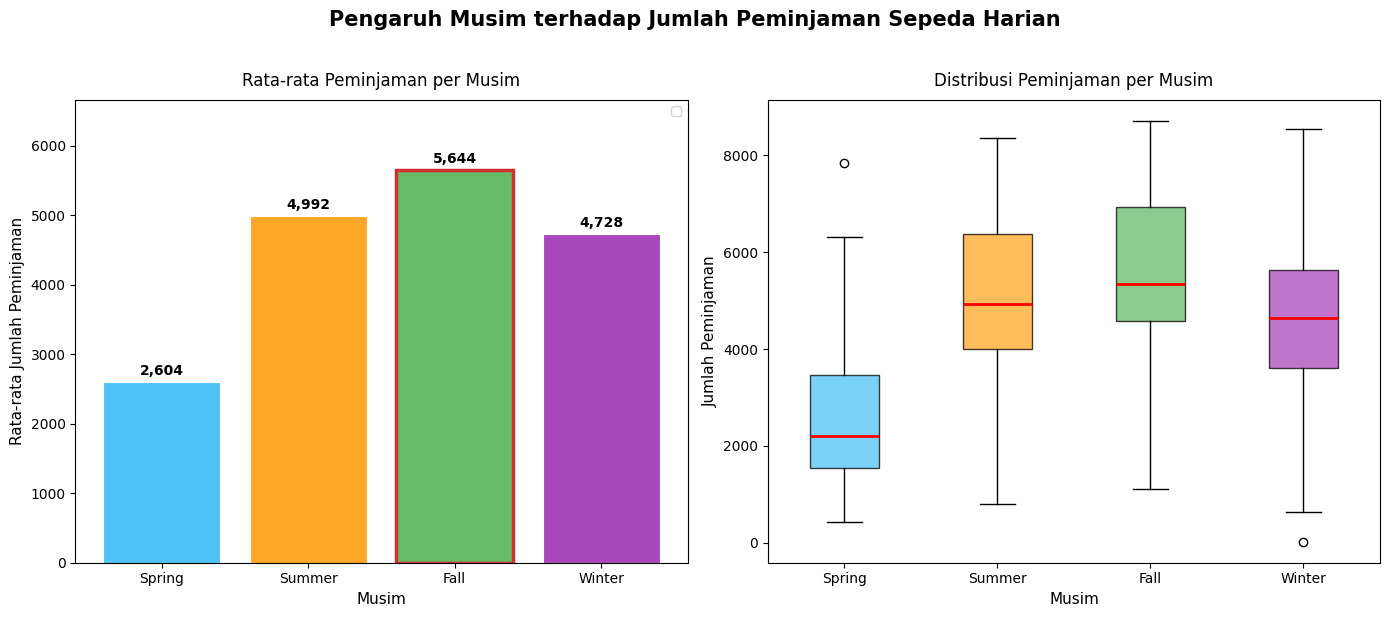

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pengaruh Musim terhadap Jumlah Peminjaman Sepeda Harian',
             fontsize=15, fontweight='bold', y=1.02)

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
palette      = ['#4FC3F7', '#FFA726', '#66BB6A', '#AB47BC']

# --- Plot 1: Bar chart rata-rata peminjaman ---
season_mean = day_clean.groupby('season_label', observed=False)['cnt'].mean().reindex(season_order)
bars = axes[0].bar(season_order, season_mean.values, color=palette, edgecolor='white', linewidth=0.8)

# Highlight bar tertinggi
max_idx = season_mean.values.argmax()
bars[max_idx].set_edgecolor('#d32f2f')
bars[max_idx].set_linewidth(2.5)

for bar, val in zip(bars, season_mean.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_title('Rata-rata Peminjaman per Musim', fontsize=12, pad=10)
axes[0].set_xlabel('Musim', fontsize=11)
axes[0].set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
axes[0].set_ylim(0, season_mean.max() * 1.18)
axes[0].legend(fontsize=9)

# --- Plot 2: Box plot distribusi ---
data_to_plot = [day_clean[day_clean['season_label'] == s]['cnt'].values for s in season_order]
bp = axes[1].boxplot(data_to_plot, labels=season_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

axes[1].set_title('Distribusi Peminjaman per Musim', fontsize=12, pad=10)
axes[1].set_xlabel('Musim', fontsize=11)
axes[1].set_ylabel('Jumlah Peminjaman', fontsize=11)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

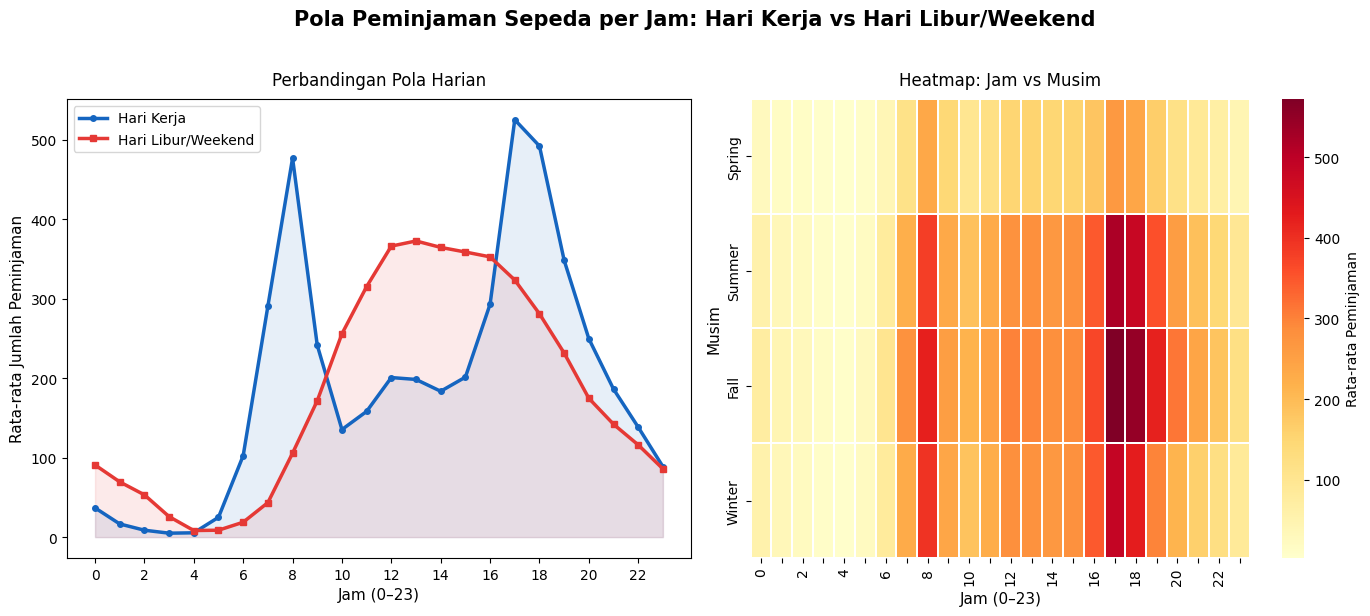

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pola Peminjaman Sepeda per Jam: Hari Kerja vs Hari Libur/Weekend',
             fontsize=15, fontweight='bold', y=1.02)

workday_data = hourly_pattern[hourly_pattern['Tipe Hari'] == 'Hari Kerja']
holiday_data = hourly_pattern[hourly_pattern['Tipe Hari'] == 'Hari Libur/Weekend']

# --- Plot 1: Line chart gabungan ---
axes[0].plot(workday_data['Jam'], workday_data['Rata-rata Peminjaman'],
             color='#1565C0', linewidth=2.5, marker='o', markersize=4, label='Hari Kerja')
axes[0].plot(holiday_data['Jam'], holiday_data['Rata-rata Peminjaman'],
             color='#E53935', linewidth=2.5, marker='s', markersize=4, label='Hari Libur/Weekend')

# Annotate peaks
wd_peak_hr  = workday_data.loc[workday_data['Rata-rata Peminjaman'].idxmax()]
hd_peak_hr  = holiday_data.loc[holiday_data['Rata-rata Peminjaman'].idxmax()]

axes[0].fill_between(workday_data['Jam'], workday_data['Rata-rata Peminjaman'], alpha=0.1, color='#1565C0')
axes[0].fill_between(holiday_data['Jam'], holiday_data['Rata-rata Peminjaman'], alpha=0.1, color='#E53935')
axes[0].set_title('Perbandingan Pola Harian', fontsize=12, pad=10)
axes[0].set_xlabel('Jam (0–23)', fontsize=11)
axes[0].set_ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
axes[0].legend(fontsize=10)

# --- Plot 2: Heatmap jam vs tipe hari (menggunakan season) ---
heatmap_data = hour_clean.groupby(['hr', 'season_label'])['cnt'].mean().unstack()
heatmap_data = heatmap_data[['Spring', 'Summer', 'Fall', 'Winter']]

sns.heatmap(heatmap_data.T, ax=axes[1], cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Rata-rata Peminjaman'})
axes[1].set_title('Heatmap: Jam vs Musim', fontsize=12, pad=10)
axes[1].set_xlabel('Jam (0–23)', fontsize=11)
axes[1].set_ylabel('Musim', fontsize=11)

plt.show()

**Insight**
<br></br>
**Pertanyaan 1:**

- **Fall (Gugur)** merupakan musim dengan rata-rata peminjaman sepeda tertinggi (~5.644 per hari), diikuti **Summer (Panas)** dan **Winter (Dingin)**.
- **Spring (Semi)** memiliki rata-rata terendah (~2.604), hampir separuh dari Fall, kemungkinan disebabkan cuaca yang masih tidak menentu.
- Box plot menunjukkan Fall dan Summer memiliki distribusi yang lebih tinggi dan tersebar, mengindikasikan variasi permintaan yang besar pada musim tersebut.
- Operator bike-sharing disarankan meningkatkan ketersediaan armada pada musim Fall dan Summer.
<br></br>
**Pertanyaan 2:**

- **Hari Kerja** memperlihatkan pola bimodal yang khas: dua puncak tajam pada **pukul 08:00** (jam berangkat kerja) dan **pukul 17:00–18:00** (jam pulang kerja), mengindikasikan dominasi penggunaan untuk komuter.
- **Hari Libur/Weekend** menunjukkan pola unimodal dengan puncak yang lebih landai sekitar **pukul 12:00–14:00**, mencerminkan penggunaan rekreasional.
- Heatmap mengonfirmasi bahwa jam sibuk (07:00–09:00 dan 16:00–19:00) konsisten tinggi di semua musim, terutama Fall dan Summer.
- Strategi redistribusi sepeda sebaiknya mempertimbangkan dua kondisi ini secara terpisah.

## Analisis Lanjutan (Opsional)

=== Distribusi Cluster Permintaan ===
                    jumlah_hari  rata_rata  persen_musim_gugur
demand_cluster                                                
Low (<2000)                  98     1394.8                 3.1
Medium (2000-4000)          181     3108.0                 9.4
High (4000-6000)            272     4862.6                33.1
Very High (>6000)           180     7060.1                43.3
=== Komposisi Musim per Cluster (%) ===
season_label        Fall  Spring  Summer  Winter
demand_cluster                                  
Low (<2000)          3.0    81.0     9.0     7.0
Medium (2000-4000)   9.0    38.0    20.0    33.0
High (4000-6000)    33.0    11.0    28.0    28.0
Very High (>6000)   43.0     3.0    34.0    19.0


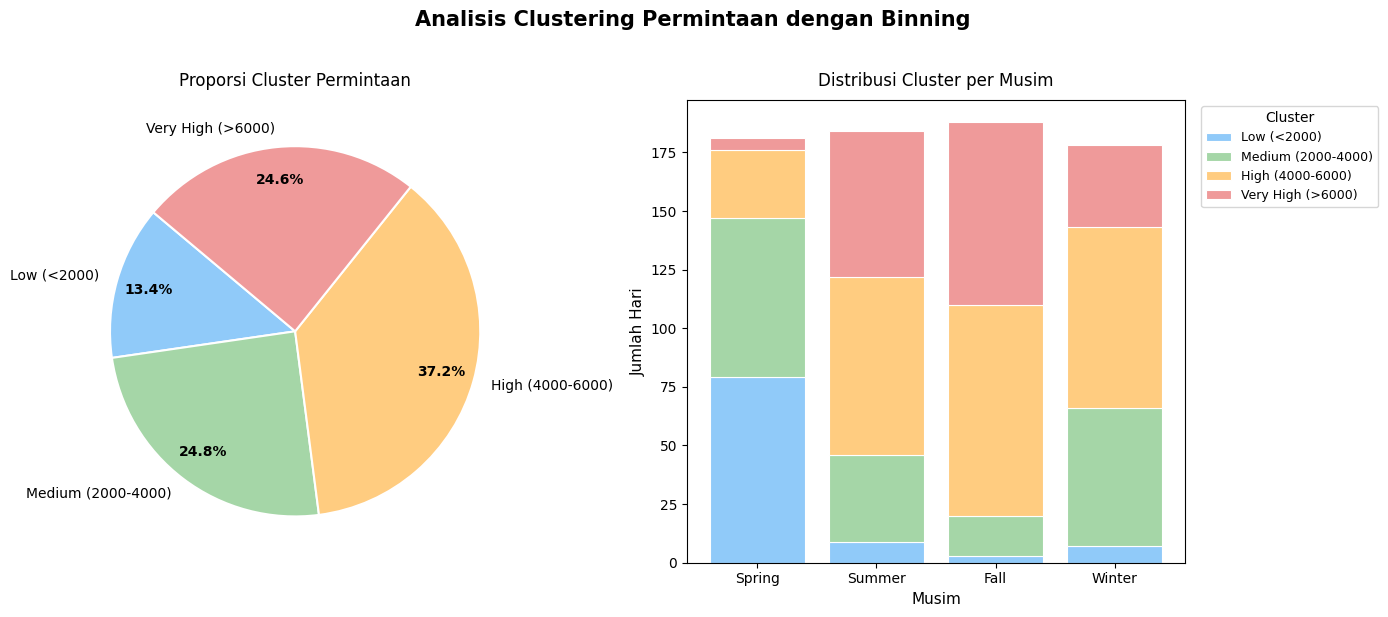

Data disimpan: main_data.csv (731 baris, 22 kolom)


,dteday,season,season_label,yr,year_label,mnth,weekday,weekday_label,workingday,holiday,...,temp,temp_celsius,hum,hum_percent,windspeed,windspeed_kph,casual,registered,cnt,demand_cluster
726,2012-12-27,1,Spring,1,2012,12,4,Thursday,1,0,...,0.254167,10.420847,0.652917,65.2917,0.350133,23.458911,247,1867,2114,Medium (2000-4000)
727,2012-12-28,1,Spring,1,2012,12,5,Friday,1,0,...,0.253333,10.386653,0.590000,59.0000,0.155471,10.416557,644,2451,3095,Medium (2000-4000)
728,2012-12-29,1,Spring,1,2012,12,6,Saturday,0,0,...,0.253333,10.386653,0.752917,75.2917,0.124383,8.333661,159,1182,1341,Low (<2000)
729,2012-12-30,1,Spring,1,2012,12,0,Sunday,0,0,...,0.255833,10.489153,0.483333,48.3333,0.350754,23.500518,364,1432,1796,Low (<2000)
730,2012-12-31,1,Spring,1,2012,12,1,Monday,1,0,...,0.215833,8.849153,0.577500,57.7500,0.154846,10.374682,439,2290,2729,Medium (2000-4000)


In [ ]:
# Clustering dengan Binning berdasarkan jumlah peminjaman
bins   = [0, 2000, 4000, 6000, day_clean['cnt'].max() + 1]
labels = ['Low (<2000)', 'Medium (2000-4000)', 'High (4000-6000)', 'Very High (>6000)']

day_clean['demand_cluster'] = pd.cut(day_clean['cnt'], bins=bins, labels=labels, right=False)

cluster_summary = day_clean.groupby('demand_cluster', observed=False).agg(
    jumlah_hari=('cnt', 'count'),
    rata_rata=('cnt', 'mean'),
    persen_musim_gugur=('season_label', lambda x: (x == 'Fall').mean() * 100)
).round(1)

print('=== Distribusi Cluster Permintaan ===')
print(cluster_summary)

# Distribusi cluster per musim
cluster_season = pd.crosstab(
    day_clean['demand_cluster'],
    day_clean['season_label'],
    normalize='index'
).round(2) * 100

print('=== Komposisi Musim per Cluster (%) ===')
print(cluster_season)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Clustering Permintaan dengan Binning',
             fontsize=15, fontweight='bold', y=1.02)

cluster_colors = ['#90CAF9', '#A5D6A7', '#FFCC80', '#EF9A9A']
cluster_counts = day_clean['demand_cluster'].value_counts(sort=False)

# --- Plot 1: Pie chart ---
wedges, texts, autotexts = axes[0].pie(
    cluster_counts.values,
    labels=cluster_counts.index,
    colors=cluster_colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
axes[0].set_title('Proporsi Cluster Permintaan', fontsize=12, pad=10)

# --- Plot 2: Stacked bar cluster per musim ---
cluster_season_cnt = pd.crosstab(day_clean['season_label'], day_clean['demand_cluster'])
cluster_season_cnt = cluster_season_cnt.reindex(season_order)

bottom = np.zeros(len(season_order))
for col, color in zip(labels, cluster_colors):
    if col in cluster_season_cnt.columns:
        vals = cluster_season_cnt[col].values
        axes[1].bar(season_order, vals, bottom=bottom, label=col, color=color,
                    edgecolor='white', linewidth=0.8)
        bottom += vals

axes[1].set_title('Distribusi Cluster per Musim', fontsize=12, pad=10)
axes[1].set_xlabel('Musim', fontsize=11)
axes[1].set_ylabel('Jumlah Hari', fontsize=11)
axes[1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.show()

# Simpan data bersih yang sudah diolah sebagai main_data.csv untuk dashboard
main_data = day_clean[[
    'dteday', 'season', 'season_label', 'yr', 'year_label',
    'mnth', 'weekday', 'weekday_label', 'workingday', 'holiday',
    'weathersit', 'weather_label', 'temp', 'temp_celsius',
    'hum', 'hum_percent', 'windspeed', 'windspeed_kph',
    'casual', 'registered', 'cnt', 'demand_cluster'
]]

main_data.to_csv('main_data.csv', index=False)
print(f'Data disimpan: main_data.csv ({main_data.shape[0]} baris, {main_data.shape[1]} kolom)')
main_data.tail()

## Conclusion

### Pertanyaan 1: Bagaimana pengaruh musim terhadap jumlah peminjaman sepeda harian?

**Fall (Musim Gugur)** adalah musim dengan permintaan tertinggi (rata-rata 5.644/hari), diikuti Summer (4.992), Winter (4.728), dan Spring terendah (2.604/hari). Perbedaan yang signifikan — hampir 2x lipat antara Fall dan Spring — mengindikasikan bahwa faktor musim sangat berpengaruh terhadap perilaku pengguna. Analisis clustering menunjukkan bahwa hampir seluruh hari berkategori *Very High* (>6.000 peminjaman) terjadi pada musim Fall dan Summer. **Rekomendasi:** Operator perlu meningkatkan kapasitas armada secara signifikan pada musim Fall–Summer dan melakukan perawatan preventif di musim Spring–Winter.

### Pertanyaan 2: Bagaimana pola peminjaman per jam pada hari kerja vs hari libur?

Terdapat perbedaan pola yang sangat jelas antara kedua tipe hari. Pada **hari kerja**, terjadi dua puncak tajam di pukul **08:00** dan **17:00–18:00** yang mencerminkan penggunaan untuk komuter. Pada **hari libur/weekend**, pola lebih merata dengan satu puncak di sekitar **pukul 12:00–14:00** yang menunjukkan penggunaan rekreasional. **Rekomendasi:** Sistem redistribusi sepeda otomatis perlu dirancang berbeda untuk hari kerja (fokus pada stasiun transit) dan hari libur (fokus pada area rekreasi dan pusat kota).